   User ID  Instagram visit score  Spending_rank
0        0                     63      24.050708
1        1                     61      25.223290
2        2                    104      18.528245
3        3                     82      86.890232
4        4                     14      31.492397
[[-0.01217181 -0.65376894]
 [-0.08743151 -0.61298749]
 [ 1.53065202 -0.84583579]
 ...
 [ 1.38013262  1.46598081]
 [ 0.89094458 -0.77618835]
 [-1.10343744  1.16650181]]


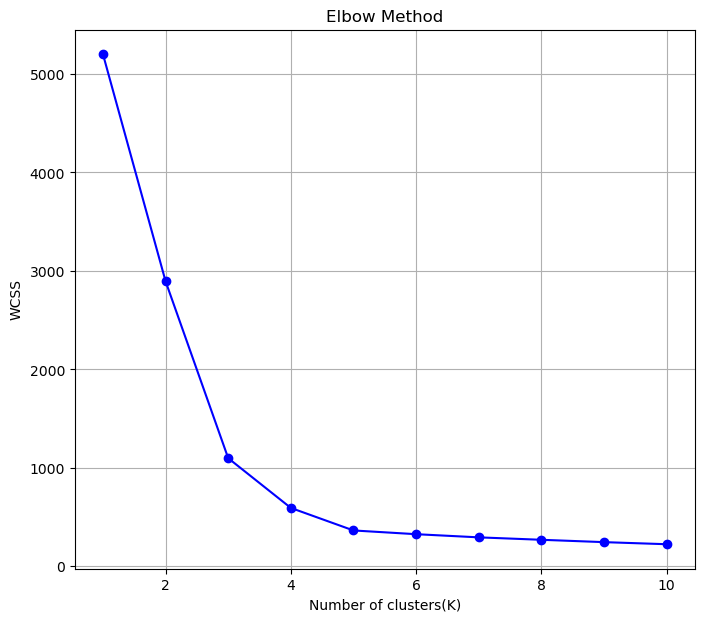

   User ID  Instagram visit score  Spending_rank  clusters
0        0                     63      24.050708         0
1        1                     61      25.223290         0
2        2                    104      18.528245         4
3        3                     82      86.890232         2
4        4                     14      31.492397         3
[[59.95192308 19.77498163]
 [39.27135678 65.26160846]
 [79.615      85.0244978 ]
 [23.91583166 24.96221997]
 [89.25790139 19.96346325]]
Cluster 0: Instagram visit = 59.95, Spending Rank = 19.77
Cluster 1: Instagram visit = 39.27, Spending Rank = 65.26
Cluster 2: Instagram visit = 79.61, Spending Rank = 85.02
Cluster 3: Instagram visit = 23.92, Spending Rank = 24.96
Cluster 4: Instagram visit = 89.26, Spending Rank = 19.96


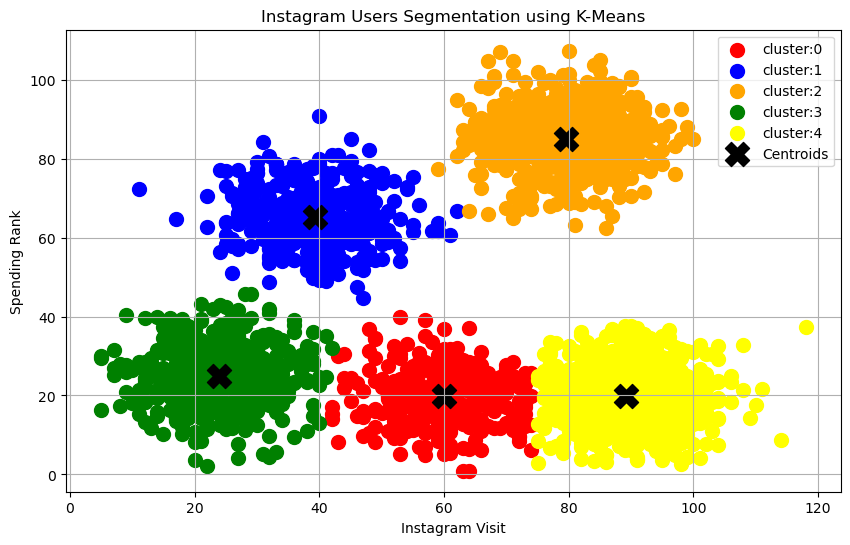

In [2]:
import os
os.environ['OMP_NUM_THREADS'] = "1"
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pickle

df = pd.read_csv(r"D:\csv\k-means-csv\Instagram-visits-clustering.csv")
print(df.head())
x = df[['Instagram visit score', 'Spending_rank']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
print(x_scaled)

wcss = []
for k in range(1,11):
    kmodel = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init=10
    )
    kmodel.fit(x_scaled)
    wcss.append(kmodel.inertia_)

plt.figure(figsize=(8,7))
plt.plot( range(1, 11), wcss, color="blue", marker="o")
plt.xlabel('Number of clusters(K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid(True)
plt.show()
    
k=5
kmean_model = KMeans(
            n_clusters = k,
            random_state = 42,
            n_init=10
        )
clusters = kmean_model.fit_predict(x_scaled)
df['clusters'] = clusters
print(df.head())
centroids  = scaler.inverse_transform(kmean_model.cluster_centers_)
print(centroids)
for i, center in enumerate(centroids):
    print(
        f"Cluster {i}: "
        f"Instagram visit = {center[0]:.2f}, "
        f"Spending Rank = {center[1]:.2f}"
    )

# print('my_clusters ',df['clusters'])
colors = ['red', 'blue', 'orange', 'green', 'Yellow']
plt.figure(figsize=(10,6))
for i in range(k):
    clustered_data = df[df['clusters'] == i]
    # print('my_clustered_data ', clustered_data['Instagram visit score'],clustered_data['Spending_rank'])
    # print('<br>')
    plt.scatter(clustered_data['Instagram visit score'], clustered_data['Spending_rank'], s = 100, color = colors[i], label = f"cluster:{i}")

plt.scatter(centroids[:,0], centroids[:,1], color="black", s = 300, marker="X", label="Centroids"  )
plt.xlabel("Instagram Visit")
plt.ylabel("Spending Rank")
plt.title("Instagram Users Segmentation using K-Means")
plt.legend()
plt.grid(True)
plt.show()

with open(r"D:\Python-Course\ML-Course\test\Machine-Learning-Algorithm\K-Means\k_means_model.pkl" ,"wb") as f: 
    pickle.dump(kmean_model, f) 